# Study 261 -- Put-Call-Ratio
## For the quants: predictive regression, HAC tests, random-timing null, sub-periods

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from put_call_ratio import data, strategy as st

CACHE_PATH = data.GSPC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    panel = data.build_real_panel(fetch=False)
    sig = st.extreme_signal(panel["pcr"], q=0.80)
    tr = st.timing_returns(panel, q=0.80, one_way_bps=5.0)
    print(f"Real panel loaded: {len(panel)} months  {panel.index[0].date()} -> {panel.index[-1].date()}")
    print(f"Active (post-burn-in) months: {len(tr)}")
else:
    panel = sig = tr = None
    print("No real ^GSPC cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 276 months  2003-01-31 -> 2025-12-31
Active (post-burn-in) months: 240


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 276, 'n_active': 240, 'fingerprint': '8edbde520f70', 'pcr_mean': 0.913, 'pcr_std': 0.107, 'reg_slope': -0.0007, 'reg_t': -0.16, 'reg_r2': 0.0002, 'reg_n': 240, 'in_mkt_frac': 0.262, 'strat_ann': 2.18, 'strat_t': 1.02, 'strat_sr': 0.2, 'strat_hit': 0.163, 'strat_dd': -0.371, 'strat_net_ann': 2.02, 'strat_net_t': 0.95, 'bh_ann': 9.63, 'bh_t': 2.81, 'bh_sr': 0.64, 'bh_dd': -0.526, 'n_switches': 64, 'fear_n': 63, 'fear_mean': 0.693, 'fear_t': 1.02, 'calm_n': 177, 'calm_mean': 0.842, 'calm_t': 3.11, 'fear_minus_calm': -0.149, 'welch_t': -0.18, 'welch_p': 0.856, 'perm_p': 0.615, 'rand_mean': 0.815, 'sub1_lab': '2006-2012', 'sub1': -2.0, 'sub1_t': -0.41, 'sub1_n': 84, 'sub1_bh': 3.7, 'sub2_lab': '2013-2019', 'sub2': 3.5, 'sub2_t': 1.91, 'sub2_n': 84, 'sub2_bh': 11.6, 'sub3_lab': '2020-2025', 'sub3': 5.5, 'sub3_t': 1.69, 'sub3_n': 72, 'sub3_bh': 14.3, 'syn_null_t': -0.95, 'syn_live_t': 6.98, 'syn_strong_t': 14.81}


## Positive control: the engine finds a contrarian edge when one is planted

`data.synthetic_panel(contrarian_beta=b)` plants `fwd_ret = base + b*(pcr-mean) + noise`.
A positive `b` is the folklore (high fear precedes high returns). The predictive
regression must recover it at `b>0` and read ~zero at `b=0`.


In [3]:
for beta, lab in [(0.0, "null"), (0.15, "planted"), (0.30, "strong")]:
    dfx, _ = data.synthetic_panel(contrarian_beta=beta, seed=261)
    reg = st.predictive_regression(dfx)
    print(f"  beta={beta:<4} ({lab:<7}): slope={reg['slope']:+.4f}  HAC t={reg['tstat']:+.2f}  R2={reg['r2']:.3f}")
print()
print("-> Engine reads ~0 on the null and a strongly positive slope when fear is")
print("   genuinely informative. The machinery is truthful.")


  beta=0.0  (null   ): slope=-0.0021  HAC t=-0.95  R2=0.003


  beta=0.15 (planted): slope=+0.0156  HAC t=+6.98  R2=0.145


  beta=0.3  (strong ): slope=+0.0333  HAC t=+14.81  R2=0.435

-> Engine reads ~0 on the null and a strongly positive slope when fear is
   genuinely informative. The machinery is truthful.


## Real tape: the continuous predictive regression is flat

In [4]:
if HAVE_REAL:
    reg = st.predictive_regression(panel)
    print("=== Next-month S&P return on expanding put/call z-score (HAC) ===")
    print(f"  slope = {reg['slope']:+.4f} per 1-sigma of put/call")
    print(f"  HAC t = {reg['tstat']:+.2f}")
    print(f"  R^2   = {reg['r2']:.4f}   n = {reg['n']}")
else:
    print(f"Frozen: slope={R['reg_slope']:+.4f}  HAC t={R['reg_t']:+.2f}  R2={R['reg_r2']:.4f}  n={R['reg_n']}")
print()
print("A contrarian edge would show a POSITIVE slope (high fear -> high fwd return).")
print(f"The real slope is essentially zero (t = {R['reg_t']:+.2f}) -- no predictive content.")


=== Next-month S&P return on expanding put/call z-score (HAC) ===
  slope = -0.0007 per 1-sigma of put/call
  HAC t = -0.16
  R^2   = 0.0002   n = 240

A contrarian edge would show a POSITIVE slope (high fear -> high fwd return).
The real slope is essentially zero (t = -0.16) -- no predictive content.


## Extreme-fear timing rule vs buy-and-hold (gross and net of costs)

In [5]:
if HAVE_REAL:
    s_strat = st.summarize(tr["strat"])
    s_net   = st.summarize(tr["strat_net"])
    s_bh    = st.summarize(tr["bh"])
    n_switch = int(tr["in_mkt"].diff().abs().sum())
    print(f"Active months: {len(tr)}   in-market fraction: {tr['in_mkt'].mean():.1%}   switches: {n_switch}")
    print()
    print(f"STRAT gross : {s_strat['mean']*1200:+.2f}%/yr  HAC t={s_strat['tstat']:+.2f}  SR(ann)={s_strat['sharpe']*12**0.5:+.2f}  hit={s_strat['hit_rate']:.3f}  maxDD={s_strat['max_drawdown']:.1%}")
    print(f"STRAT net   : {s_net['mean']*1200:+.2f}%/yr  HAC t={s_net['tstat']:+.2f}  (5 bps one-way on each switch)")
    print(f"BUY & HOLD  : {s_bh['mean']*1200:+.2f}%/yr  HAC t={s_bh['tstat']:+.2f}  SR(ann)={s_bh['sharpe']*12**0.5:+.2f}  maxDD={s_bh['max_drawdown']:.1%}")
else:
    print(f"Frozen STRAT gross: {R['strat_ann']:+.2f}%/yr  t={R['strat_t']:+.2f}  SR={R['strat_sr']:+.2f}  maxDD={R['strat_dd']:.1%}")
    print(f"Frozen STRAT net  : {R['strat_net_ann']:+.2f}%/yr  t={R['strat_net_t']:+.2f}")
    print(f"Frozen BUY & HOLD : {R['bh_ann']:+.2f}%/yr  t={R['bh_t']:+.2f}  SR={R['bh_sr']:+.2f}  maxDD={R['bh_dd']:.1%}")
print()
print("The timing rule has a LOWER Sharpe than buy-and-hold and gives up ~7.5%/yr")
print("of return for a modestly smaller drawdown -- a poor trade, not an edge.")


Active months: 240   in-market fraction: 26.2%   switches: 64

STRAT gross : +2.18%/yr  HAC t=+1.02  SR(ann)=+0.20  hit=0.163  maxDD=-37.1%
STRAT net   : +2.02%/yr  HAC t=+0.95  (5 bps one-way on each switch)
BUY & HOLD  : +9.63%/yr  HAC t=+2.81  SR(ann)=+0.64  maxDD=-52.6%

The timing rule has a LOWER Sharpe than buy-and-hold and gives up ~7.5%/yr
of return for a modestly smaller drawdown -- a poor trade, not an edge.


## Conditional next-month return and the Welch test

In [6]:
if HAVE_REAL:
    s = sig.iloc[36:]
    fwd = panel["fwd_ret"].iloc[36:]
    fear = fwd[s == 1]; calm = fwd[s == 0]
    from scipy import stats as sc
    wt, wp = sc.ttest_ind(fear, calm, equal_var=False)
    print(f"After extreme fear: {fear.mean()*100:+.3f}%/mo  HAC t={st.summarize(fear)['tstat']:+.2f}  n={len(fear)}")
    print(f"After calm        : {calm.mean()*100:+.3f}%/mo  HAC t={st.summarize(calm)['tstat']:+.2f}  n={len(calm)}")
    print(f"Difference        : {(fear.mean()-calm.mean())*100:+.3f}%/mo  Welch t={wt:+.2f}  p={wp:.3f}")
else:
    print(f"After extreme fear: {R['fear_mean']:+.3f}%/mo  t={R['fear_t']:+.2f}  n={R['fear_n']}")
    print(f"After calm        : {R['calm_mean']:+.3f}%/mo  t={R['calm_t']:+.2f}  n={R['calm_n']}")
    print(f"Difference        : {R['fear_minus_calm']:+.3f}%/mo  Welch t={R['welch_t']:+.2f}  p={R['welch_p']:.3f}")
print()
print("The conditional difference is the WRONG sign and not remotely significant.")


After extreme fear: +0.693%/mo  HAC t=+1.02  n=63
After calm        : +0.842%/mo  HAC t=+3.11  n=177
Difference        : -0.149%/mo  Welch t=-0.18  p=0.856

The conditional difference is the WRONG sign and not remotely significant.


## Random-timing null: is the fear-timed selection special?

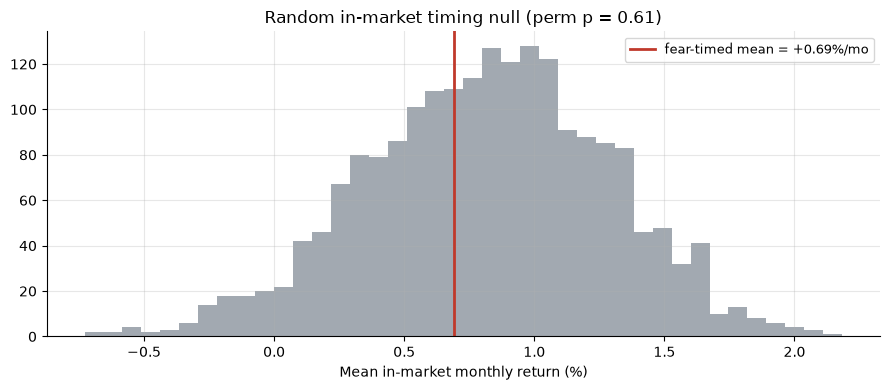

Permutation p (random >= fear-timed): 0.615
-> A random pick of the same number of in-market months beats the fear-timed
   selection 62% of the time. The signal carries no timing skill.


In [7]:
if HAVE_REAL:
    frac = tr["in_mkt"].mean()
    rand = st.random_timing_returns(panel, in_mkt_frac=frac, n_draws=2000, seed=261)
    fwd = panel["fwd_ret"].iloc[36:]
    fear_mean = fwd[sig.iloc[36:] == 1].mean()
    perm_p = float((rand >= fear_mean).mean())
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(rand.values*100, bins=40, color=GREY, alpha=0.8)
    ax.axvline(fear_mean*100, color=RED, lw=2, label=f"fear-timed mean = {fear_mean*100:+.2f}%/mo")
    ax.set_title(f"Random in-market timing null (perm p = {perm_p:.2f})")
    ax.set_xlabel("Mean in-market monthly return (%)")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"Permutation p (random >= fear-timed): {perm_p:.3f}")
else:
    print(f"Frozen: random in-market mean = {R['rand_mean']:+.2f}%/mo")
    print(f"Permutation p (random >= fear-timed): {R['perm_p']:.3f}")
print("-> A random pick of the same number of in-market months beats the fear-timed")
print(f"   selection {R['perm_p']*100:.0f}% of the time. The signal carries no timing skill.")


## Sub-period stability

  2006-2012: strat -2.0%/yr t=-0.41 n=84 | buy-hold +3.7%/yr
  2013-2019: strat +3.5%/yr t=+1.91 n=84 | buy-hold +11.6%/yr
  2020-2025: strat +5.5%/yr t=+1.69 n=72 | buy-hold +14.3%/yr


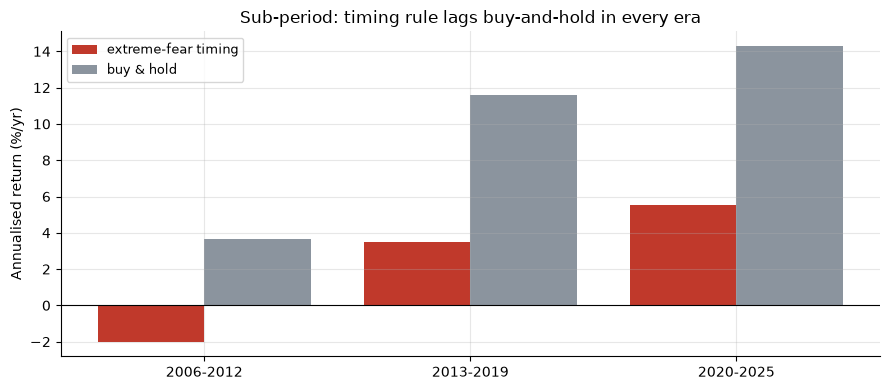

In every sub-period the rule underperforms simply owning the index.


In [8]:
if HAVE_REAL:
    rows = []
    for lab, a, b in [("2006-2012", "2006", "2012"), ("2013-2019", "2013", "2019"), ("2020-2025", "2020", "2025")]:
        sub = tr["strat"][a:b]; sbh = tr["bh"][a:b]
        s = st.summarize(sub); sb = st.summarize(sbh)
        rows.append({"period": lab, "strat_ann": s["mean"]*1200, "t": s["tstat"], "n": s["n"], "bh_ann": sb["mean"]*1200})
        print(f"  {lab}: strat {s['mean']*1200:+.1f}%/yr t={s['tstat']:+.2f} n={s['n']} | buy-hold {sb['mean']*1200:+.1f}%/yr")
    sub_df = pd.DataFrame(rows)
else:
    sub_df = pd.DataFrame([
        {"period": R["sub1_lab"], "strat_ann": R["sub1"], "t": R["sub1_t"], "n": R["sub1_n"], "bh_ann": R["sub1_bh"]},
        {"period": R["sub2_lab"], "strat_ann": R["sub2"], "t": R["sub2_t"], "n": R["sub2_n"], "bh_ann": R["sub2_bh"]},
        {"period": R["sub3_lab"], "strat_ann": R["sub3"], "t": R["sub3_t"], "n": R["sub3_n"], "bh_ann": R["sub3_bh"]},
    ])
    for _, r in sub_df.iterrows():
        print(f"  {r['period']}: strat {r['strat_ann']:+.1f}%/yr t={r['t']:+.2f} n={int(r['n'])} | buy-hold {r['bh_ann']:+.1f}%/yr")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(sub_df))
ax.bar(x-0.2, sub_df["strat_ann"], width=0.4, color=RED, label="extreme-fear timing")
ax.bar(x+0.2, sub_df["bh_ann"], width=0.4, color=GREY, label="buy & hold")
ax.set_xticks(x); ax.set_xticklabels(sub_df["period"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Annualised return (%/yr)")
ax.set_title("Sub-period: timing rule lags buy-and-hold in every era")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("In every sub-period the rule underperforms simply owning the index.")


## Verdict

In [9]:
print("=== Study 261 -- Put-Call-Ratio ===")
print()
print(f"Signal: NONE")
print(f"  Predictive regression slope HAC t = {R['reg_t']:+.2f} (flat).")
print(f"  Extreme-fear months: {R['fear_mean']:+.2f}%/mo vs calm {R['calm_mean']:+.2f}%/mo (Welch t={R['welch_t']:+.2f}, wrong sign).")
print(f"  Random-timing permutation p = {R['perm_p']:.2f} -- no timing skill beyond chance.")
print()
print(f"Tradability: MIRAGE")
print(f"  Rule earns +{R['strat_ann']:.1f}%/yr vs index +{R['bh_ann']:.1f}%/yr; lower Sharpe ({R['strat_sr']:.2f} vs {R['bh_sr']:.2f}).")
print(f"  In-market only {R['in_mkt_frac']*100:.0f}% of months -> misses the bull market.")
print(f"  Net of 5bps switch costs, still +{R['strat_net_ann']:.1f}%/yr (costs are not the problem; the signal is).")
print()
print("Honesty: one-month execution lag built in; price-only S&P (dividends excluded,")
print("  so buy-and-hold's true edge is even larger); ~23yr sample dominated by a few")
print("  crisis spikes -- the few 'extreme' episodes are not independent.")
print()
print("Bottom line: None/Mirage -- the put/call ratio measures fear well but does")
print("  NOT time market bottoms.")


=== Study 261 -- Put-Call-Ratio ===

Signal: NONE
  Predictive regression slope HAC t = -0.16 (flat).
  Extreme-fear months: +0.69%/mo vs calm +0.84%/mo (Welch t=-0.18, wrong sign).
  Random-timing permutation p = 0.61 -- no timing skill beyond chance.

Tradability: MIRAGE
  Rule earns +2.2%/yr vs index +9.6%/yr; lower Sharpe (0.20 vs 0.64).
  In-market only 26% of months -> misses the bull market.
  Net of 5bps switch costs, still +2.0%/yr (costs are not the problem; the signal is).

Honesty: one-month execution lag built in; price-only S&P (dividends excluded,
  so buy-and-hold's true edge is even larger); ~23yr sample dominated by a few
  crisis spikes -- the few 'extreme' episodes are not independent.

Bottom line: None/Mirage -- the put/call ratio measures fear well but does
  NOT time market bottoms.
